# CSE 445 — Assignment 1 — Notebook 1: Dataset Exploration & Preprocessing
Group: J
Members: 1.Farha Anjum Afia, 2022-3-60-237
         2.Rukaiah Bintay Morshed, 2022-3-60-334
         3.Kaniz Reza Mithila, 2022-3-60-052
         4.Redwan Ahmed, 2022-3-60-155
Dataset: Dental OPG Object Detection Dataset (Cavities, Damage, Infection, Wisdom)
Source: Mendeley Data, DOI 10.17632/wxv6h9p39g.1

In [1]:
!pip install ultralytics -q

import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.3 MB/s eta 0:00:00
GPU available: True
GPU name: Tesla T4


 Find the object detection folder

In [2]:
import os

DETECTION_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        DETECTION_ROOT = root
        break

print("Detection dataset root:", DETECTION_ROOT)
print("\nContents of that folder:")
print(os.listdir(DETECTION_ROOT) if DETECTION_ROOT else "NOT FOUND — check the Add Data panel")

print("\nFull structure of your uploaded dataset (for reference):")
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    if level <= 3:
        print('  ' * level + os.path.basename(root) + '/')

Detection dataset root: /kaggle/input/datasets/redwan155/dental-dataset/Dental OPG Image dataset/Object detection

Contents of that folder:
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test', 'train']

Full structure of your uploaded dataset (for reference):
input/
  datasets/
    redwan155/
      dental-dataset/


In [3]:
import yaml

with open(os.path.join(DETECTION_ROOT, 'data.yaml')) as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['Cavities', 'Damage', 'Infection', 'Wisdom'], 'roboflow': {'workspace': 'dental-disease-detection-hpn1d', 'project': 'demo-wjml3', 'version': 8, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/dental-disease-detection-hpn1d/demo-wjml3/dataset/8'}}


CONFIG cell

In [4]:
CLASS_NAMES = data_yaml['names']          # pulled from data.yaml, not retyped by hand
NUM_CLASSES = data_yaml['nc']
SPLITS = ['train', 'valid', 'test']
IMG_SIZE = 640   # standard YOLO default; revisit after we see bbox size stats in EDA

# Decision: keep Roboflow's existing split rather than re-shuffling all 10,000 images,
# since re-splitting risks time with no clear benefit given the deadline.
# We verify (not recreate) this split for leakage/stratification in the next steps.
EXPECTED_COUNTS = {'train': 7985, 'valid': 1402, 'test': 613}

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)

Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Num classes: 4


Dataset integrity check

In [5]:
from pathlib import Path
from PIL import Image

def check_split(split):
    img_dir = Path(DETECTION_ROOT) / split / 'images'
    lbl_dir = Path(DETECTION_ROOT) / split / 'labels'

    images = {p.stem for p in img_dir.glob('*.jpg')}
    labels = {p.stem for p in lbl_dir.glob('*.txt')}

    missing_labels = images - labels
    orphan_labels = labels - images

    corrupt = []
    for p in img_dir.glob('*.jpg'):
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            corrupt.append(p.name)

    print(f"--- {split} ---")
    print(f"Images: {len(images)} | Labels: {len(labels)}")
    print(f"Images missing a label file: {len(missing_labels)}")
    print(f"Label files with no matching image: {len(orphan_labels)}")
    print(f"Corrupt images: {len(corrupt)}")
    if missing_labels:
        print("  e.g. missing labels for:", list(missing_labels)[:5])
    if corrupt:
        print("  e.g. corrupt:", corrupt[:5])
    print()

for split in SPLITS:
    check_split(split)

--- train ---
Images: 7985 | Labels: 7985
Images missing a label file: 0
Label files with no matching image: 0
Corrupt images: 0

--- valid ---
Images: 1402 | Labels: 1402
Images missing a label file: 0
Label files with no matching image: 0
Corrupt images: 0

--- test ---
Images: 613 | Labels: 613
Images missing a label file: 0
Label files with no matching image: 0
Corrupt images: 0



Parse every label file into one structured table.

In [6]:
import pandas as pd
from PIL import Image
from pathlib import Path

def parse_split(split):
    img_dir = Path(DETECTION_ROOT) / split / 'images'
    lbl_dir = Path(DETECTION_ROOT) / split / 'labels'

    rows, image_meta = [], []

    for lbl_path in lbl_dir.glob('*.txt'):
        img_path = img_dir / (lbl_path.stem + '.jpg')
        with Image.open(img_path) as im:
            img_w, img_h = im.size

        image_meta.append({'split': split, 'image_id': lbl_path.stem, 'img_w': img_w, 'img_h': img_h})

        with open(lbl_path) as f:
            lines = [l for l in f.read().strip().split('\n') if l.strip()]

        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])
            x_c, y_c, w, h = map(float, parts[1:5])
            box_w_px, box_h_px = w * img_w, h * img_h

            rows.append({
                'split': split, 'image_id': lbl_path.stem,
                'class_id': class_id, 'class_name': CLASS_NAMES[class_id],
                'x_center_norm': x_c, 'y_center_norm': y_c,
                'width_norm': w, 'height_norm': h,
                'box_width_px': box_w_px, 'box_height_px': box_h_px,
                'area_px': box_w_px * box_h_px,
                'img_w': img_w, 'img_h': img_h,
            })

    return pd.DataFrame(rows), pd.DataFrame(image_meta)

all_boxes, all_images = [], []
for split in SPLITS:
    b, i = parse_split(split)
    all_boxes.append(b)
    all_images.append(i)

boxes_df = pd.concat(all_boxes, ignore_index=True)
images_df = pd.concat(all_images, ignore_index=True)

print("Total boxes (instances):", len(boxes_df))
print("Total images:", len(images_df))
boxes_df.head()

Total boxes (instances): 24754
Total images: 10000


,split,image_id,class_id,class_name,x_center_norm,y_center_norm,width_norm,height_norm,box_width_px,box_height_px,area_px,img_w,img_h
0,train,Wisdom_446_jpg.rf.f88a9f56fc7d3a0d24492f76db8c...,3,Wisdom,0.871094,0.551562,0.102344,0.160156,65.5,102.5,6713.75,640,640
1,train,Wisdom_446_jpg.rf.f88a9f56fc7d3a0d24492f76db8c...,3,Wisdom,0.168750,0.577344,0.073438,0.149219,47.0,95.5,4488.50,640,640
2,train,Infection_2458_jpg.rf.16134a75f34ba0d4d1dbab0e...,2,Infection,0.764062,0.842187,0.781250,0.842187,500.0,539.0,269500.00,640,640
3,train,Infection_2458_jpg.rf.16134a75f34ba0d4d1dbab0e...,2,Infection,0.151562,0.682813,0.162500,0.671875,104.0,430.0,44720.00,640,640
4,train,Infection_2617_jpg.rf.510c923b4075c968c54b18f4...,2,Infection,0.800000,0.956250,0.785937,0.960938,503.0,615.0,309345.00,640,640


Class distribution (instance-level), with imbalance flag:

class_name  Cavities  Damage  Infection  Wisdom  total
split                                                 
test             760    1003        209      30   2002
train           4659    7741       3009    3506  18915
valid           1370    1951        469      47   3837

Overall instances per class:
 class_name
Damage       10695
Cavities      6789
Infection     3687
Wisdom        3583
Name: count, dtype: int64

Imbalance ratio (max class / min class): 2.98


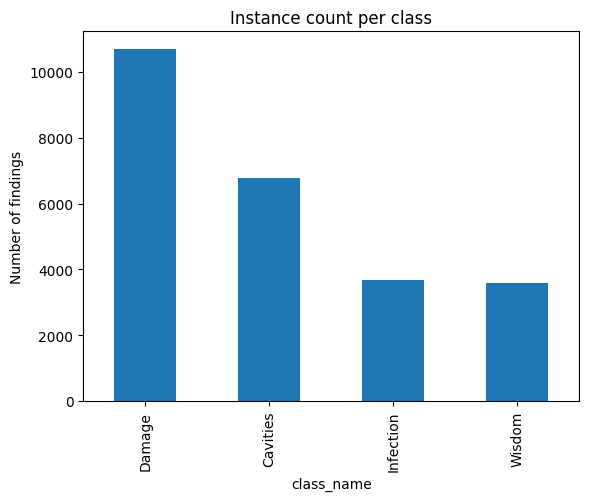

In [7]:
class_counts = boxes_df.groupby(['split', 'class_name']).size().unstack(fill_value=0)
class_counts['total'] = class_counts.sum(axis=1)
print(class_counts)

total_by_class = boxes_df['class_name'].value_counts()
print("\nOverall instances per class:\n", total_by_class)

imbalance_ratio = total_by_class.max() / total_by_class.min()
print(f"\nImbalance ratio (max class / min class): {imbalance_ratio:.2f}")

import matplotlib.pyplot as plt
total_by_class.plot(kind='bar', title='Instance count per class')
plt.ylabel('Number of findings')
plt.show()

 Image properties: resolution, aspect ratio, format:

Unique resolutions: 1
         img_w    img_h
count  10000.0  10000.0
mean     640.0    640.0
std        0.0      0.0
min      640.0    640.0
25%      640.0    640.0
50%      640.0    640.0
75%      640.0    640.0
max      640.0    640.0


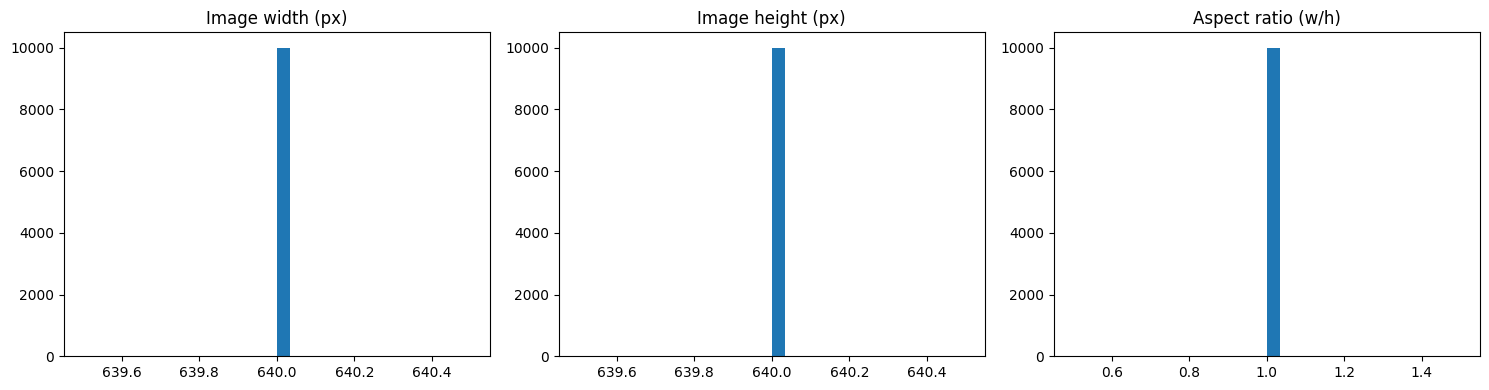

In [8]:
print("Unique resolutions:", images_df[['img_w', 'img_h']].drop_duplicates().shape[0])
print(images_df[['img_w', 'img_h']].describe())

images_df['aspect_ratio'] = images_df['img_w'] / images_df['img_h']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(images_df['img_w'], bins=30); axes[0].set_title('Image width (px)')
axes[1].hist(images_df['img_h'], bins=30); axes[1].set_title('Image height (px)')
axes[2].hist(images_df['aspect_ratio'], bins=30); axes[2].set_title('Aspect ratio (w/h)')
plt.tight_layout()
plt.show()

Bounding-box statistics: count per image, width/height/area, and the small/medium/large split

Boxes per image — summary stats:
count    9823.000000
mean        2.520004
std         1.875580
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
dtype: float64


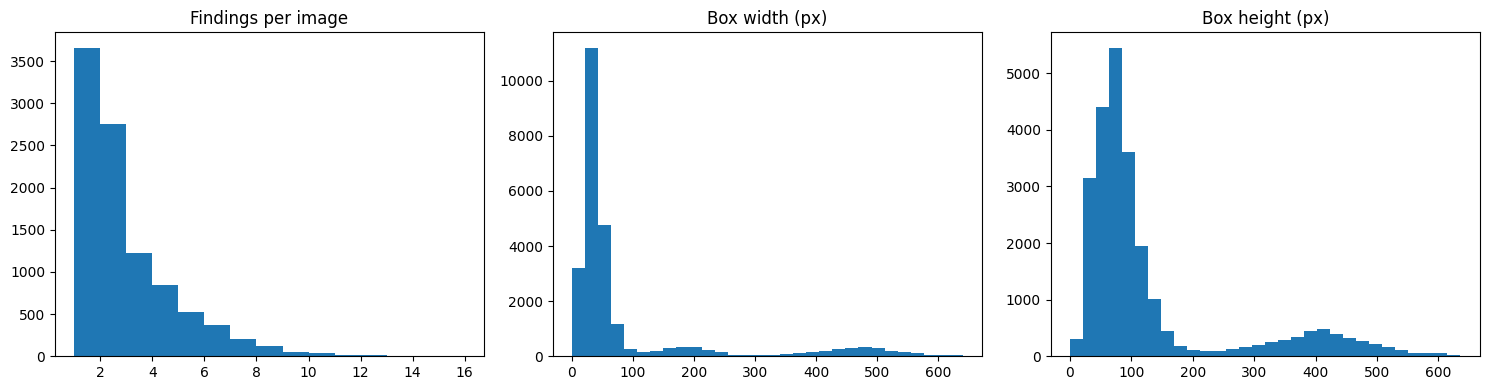


Object size distribution:
size_bucket
medium (32–96²px)    67.9
large (>96²px)       19.4
small (<32²px)       12.6
Name: proportion, dtype: float64


In [9]:
boxes_per_image = boxes_df.groupby('image_id').size()
print("Boxes per image — summary stats:")
print(boxes_per_image.describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(boxes_per_image, bins=range(1, int(boxes_per_image.max()) + 2))
axes[0].set_title('Findings per image')
axes[1].hist(boxes_df['box_width_px'], bins=30); axes[1].set_title('Box width (px)')
axes[2].hist(boxes_df['box_height_px'], bins=30); axes[2].set_title('Box height (px)')
plt.tight_layout()
plt.show()

def size_bucket(area):
    if area < 32**2: return 'small (<32²px)'
    elif area <= 96**2: return 'medium (32–96²px)'
    else: return 'large (>96²px)'

boxes_df['size_bucket'] = boxes_df['area_px'].apply(size_bucket)
print("\nObject size distribution:")
print(boxes_df['size_bucket'].value_counts(normalize=True).mul(100).round(1))

Sample annotated images at varying finding-density (low, medium, high)

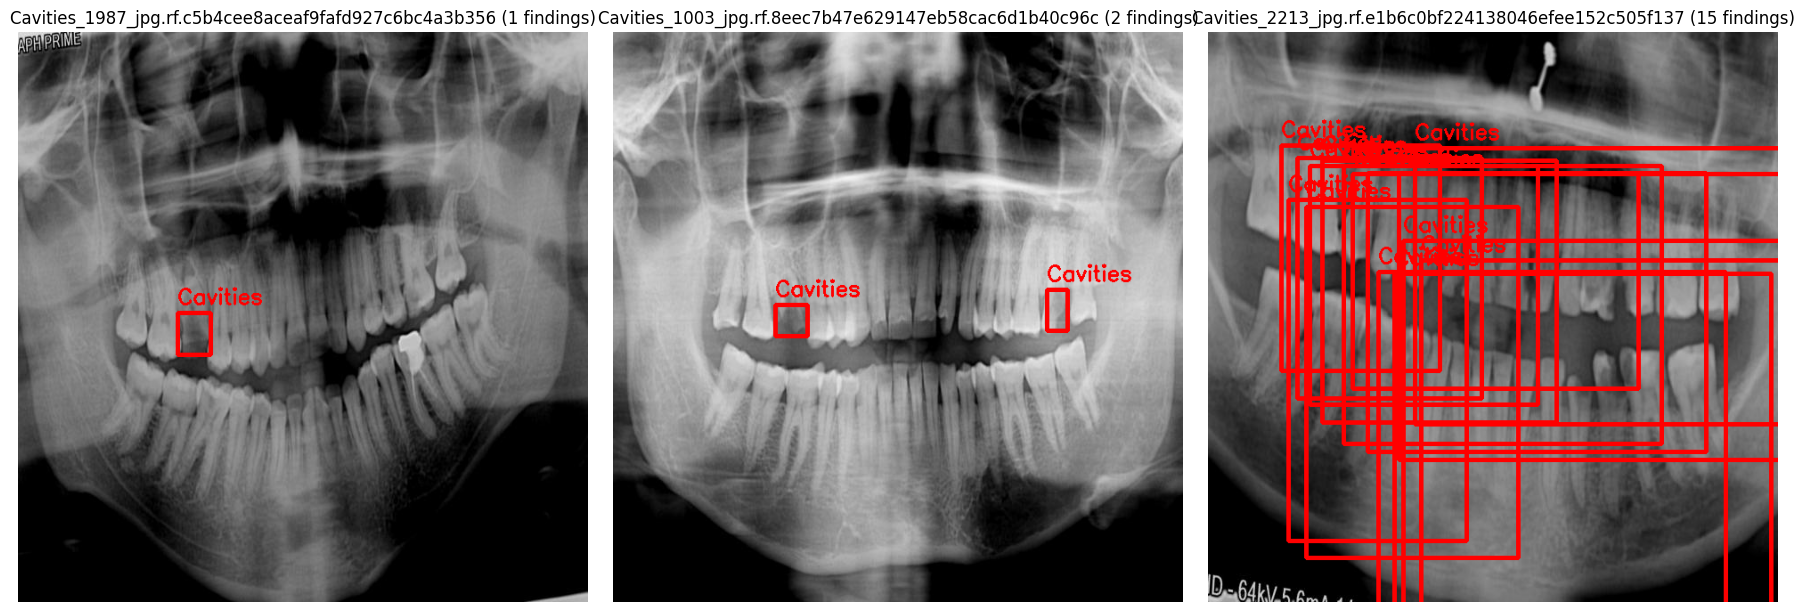

In [10]:
import cv2

def draw_boxes(image_id, split):
    img_path = Path(DETECTION_ROOT) / split / 'images' / f'{image_id}.jpg'
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    rows = boxes_df[(boxes_df['image_id'] == image_id) & (boxes_df['split'] == split)]
    for _, row in rows.iterrows():
        x_c, y_c, bw, bh = row['x_center_norm'], row['y_center_norm'], row['width_norm'], row['height_norm']
        x1, y1 = int((x_c - bw/2) * w), int((y_c - bh/2) * h)
        x2, y2 = int((x_c + bw/2) * w), int((y_c + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(img, row['class_name'], (x1, max(y1 - 10, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return img

density = boxes_per_image.reset_index()
density.columns = ['image_id', 'num_boxes']
density = density.merge(boxes_df[['image_id', 'split']].drop_duplicates(), on='image_id')

low = density[density['num_boxes'] == density['num_boxes'].min()].sample(1, random_state=42).iloc[0]
high = density.sort_values('num_boxes', ascending=False).iloc[0]
med = density.iloc[(density['num_boxes'] - density['num_boxes'].median()).abs().idxmin()]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, row in zip(axes, [low, med, high]):
    img = draw_boxes(row['image_id'], row['split'])
    ax.imshow(img)
    ax.set_title(f"{row['image_id']} ({row['num_boxes']} findings)")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
zero_finding_images = set(images_df['image_id']) - set(boxes_df['image_id'])
print(f"Images with zero findings: {len(zero_finding_images)}")

sample_ids = list(zero_finding_images)[:3]
for split in SPLITS:
    for img_id in sample_ids:
        lbl_path = Path(DETECTION_ROOT) / split / 'labels' / f'{img_id}.txt'
        if lbl_path.exists():
            content = lbl_path.read_text().strip()
            print(f"{img_id} ({split}): label file content = '{content}' (empty means confirmed background image)")

Images with zero findings: 177
Infection_1023_jpg.rf.0680af4f8e80b0fe67e3e83bd5d55c06 (train): label file content = '' (empty means confirmed background image)
Damage_1937_jpg.rf.7e4dfa1ee517c4db619a9684c921e017 (train): label file content = '' (empty means confirmed background image)
Infection_1847_jpg.rf.f82152b7165bd36ee5b4ce903d02021c (train): label file content = '' (empty means confirmed background image)


group extraction + check whether the original split already leaked:

In [12]:
def get_group_id(image_id):
    return image_id.split('_jpg.rf.')[0]

images_df['group_id'] = images_df['image_id'].apply(get_group_id)

group_sizes = images_df.groupby('group_id').size()
print("Unique source-image groups:", len(group_sizes))
print("Augmented copies per source image:")
print(group_sizes.value_counts().sort_index())

group_split_counts = images_df.groupby('group_id')['split'].nunique()
leaked_groups = group_split_counts[group_split_counts > 1]
print(f"\nGroups spread across multiple splits in the ORIGINAL Roboflow split: {len(leaked_groups)}")

Unique source-image groups: 10000
Augmented copies per source image:
1    10000
Name: count, dtype: int64

Groups spread across multiple splits in the ORIGINAL Roboflow split: 0


 exact-duplicate check (MD5 hashing), the other leakage safeguard we discussed:

In [13]:
import hashlib

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
for split in SPLITS:
    img_dir = Path(DETECTION_ROOT) / split / 'images'
    for p in img_dir.glob('*.jpg'):
        hashes.setdefault(file_hash(p), []).append((split, p.stem))

dup_hashes = {h: v for h, v in hashes.items() if len(v) > 1}
print(f"Exact byte-identical duplicate files found: {len(dup_hashes)} groups")
for h, v in list(dup_hashes.items())[:5]:
    print(v)

Exact byte-identical duplicate files found: 12 groups
[('train', 'Wisdom_1333_jpg.rf.5dff2358b3e168350f8040421ac84eda'), ('train', 'Wisdom_1338_jpg.rf.1d2c0c0fb5fc8862b56fdb041b9b3d21')]
[('train', 'Damage_336_jpg.rf.940b4bc1452614a67939020513b9f650'), ('train', 'Infection_2684_jpg.rf.c3b91214ede40cc3513ab271be573c90')]
[('train', 'Cavities_1164_jpg.rf.2233f5c14dd7c3d2179e044a40b7ec7e'), ('train', 'Wisdom_521_jpg.rf.e0fe0f87029fd0c9b712631d56225be2')]
[('train', 'Wisdom_2112_jpg.rf.f1ded0846728f1554e488ed824bdf2a9'), ('train', 'Wisdom_2110_jpg.rf.7189117d4726cbff30dc00fc405ef344')]
[('train', 'Wisdom_2117_jpg.rf.7b98c505e5c02f96df46a2e08cb6b16b'), ('train', 'Wisdom_2120_jpg.rf.dcd574a9b1dddaac4e436b904b9fcb83')]


inspect every duplicate group's full label content:

In [14]:
print(f"Total duplicate groups: {len(dup_hashes)}\n")
for h, members in dup_hashes.items():
    print(members)
    for split, stem in members:
        lbl_path = Path(DETECTION_ROOT) / split / 'labels' / f'{stem}.txt'
        content = lbl_path.read_text().strip()
        print(f"    {split}/{stem}: labels = {content!r}")
    print()

Total duplicate groups: 12

[('train', 'Wisdom_1333_jpg.rf.5dff2358b3e168350f8040421ac84eda'), ('train', 'Wisdom_1338_jpg.rf.1d2c0c0fb5fc8862b56fdb041b9b3d21')]
    train/Wisdom_1333_jpg.rf.5dff2358b3e168350f8040421ac84eda: labels = '3 0.88515625 0.39296875 0.11796875 0.16015625'
    train/Wisdom_1338_jpg.rf.1d2c0c0fb5fc8862b56fdb041b9b3d21: labels = '3 0.88984375 0.39609375 0.1359375 0.1671875'

[('train', 'Damage_336_jpg.rf.940b4bc1452614a67939020513b9f650'), ('train', 'Infection_2684_jpg.rf.c3b91214ede40cc3513ab271be573c90')]
    train/Damage_336_jpg.rf.940b4bc1452614a67939020513b9f650: labels = '1 0.7484375 0.57265625 0.040625 0.0765625\n1 0.378125 0.571875 0.034375 0.08125\n1 0.24921875 0.578125 0.0484375 0.08125'
    train/Infection_2684_jpg.rf.c3b91214ede40cc3513ab271be573c90: labels = '2 0.3984375 0.5125 0.4 0.4859375 0.39375 0.45 0.3875 0.4484375 0.3765625 0.4578125 0.365625 0.490625 0.3640625 0.515625 0.371875 0.53125 0.3890625 0.5359375 0.3984375 0.5125\n2 0.471875 0.4578125

quantify the format mismatch across the whole dataset:

In [15]:
records = []
for split in SPLITS:
    lbl_dir = Path(DETECTION_ROOT) / split / 'labels'
    for p in lbl_dir.glob('*.txt'):
        content = p.read_text().strip()
        if not content:
            continue
        for line in content.split('\n'):
            fields = line.strip().split()
            records.append({
                'split': split,
                'class_id': int(fields[0]),
                'num_fields': len(fields),
            })

fmt_df = pd.DataFrame(records)
print("Field-count distribution (5 = normal bbox, anything else = polygon):")
print(fmt_df['num_fields'].value_counts().sort_index())

print("\n% of lines per class that are polygon-format (not exactly 5 fields):")
print(fmt_df.groupby('class_id').apply(lambda g: (g['num_fields'] != 5).mean() * 100).round(1))

print("\nBroken down by split too:")
print(fmt_df.groupby(['split', 'class_id']).apply(lambda g: (g['num_fields'] != 5).mean() * 100).round(1))

Field-count distribution (5 = normal bbox, anything else = polygon):
num_fields
5     20385
9         1
11       37
13      118
15      350
17      566
19      648
21      501
23      384
25      269
27      222
29      156
31      168
33      145
35      140
37      126
39       94
41       80
43       80
45       37
47       46
49       40
51       35
53       31
55       24
57       11
59       12
61       10
63        9
65        5
67        7
69        3
71        6
73        3
75        1
77        1
79        1
83        1
85        1
Name: count, dtype: int64

% of lines per class that are polygon-format (not exactly 5 fields):
class_id
0    27.1
1     5.9
2    51.4
3     0.1
dtype: float64

Broken down by split too:
split  class_id
test   0           31.6
       1            3.1
       2           24.9
       3            0.0
train  0           26.5
       1            6.7
       2           53.8
       3            0.1
valid  0           26.5
       1            4.4
       2 

/tmp/ipykernel_23/3967687855.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(fmt_df.groupby('class_id').apply(lambda g: (g['num_fields'] != 5).mean() * 100).round(1))
/tmp/ipykernel_23/3967687855.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(fmt_df.groupby(['split', 'class_id']).apply(lambda g: (g['num_fields'] != 5).mean() * 100).round(1))


a converter that handles both formats, then re-parse every label correctly:

In [16]:
def line_to_bbox(fields):
    class_id = int(fields[0])
    nums = list(map(float, fields[1:]))
    if len(nums) == 4:
        x_c, y_c, w, h = nums
    else:
        xs, ys = nums[0::2], nums[1::2]
        min_x, max_x = min(xs), max(xs)
        min_y, max_y = min(ys), max(ys)
        x_c, y_c = (min_x + max_x) / 2, (min_y + max_y) / 2
        w, h = max_x - min_x, max_y - min_y
    return class_id, x_c, y_c, w, h

def parse_split_corrected(split):
    img_dir = Path(DETECTION_ROOT) / split / 'images'
    lbl_dir = Path(DETECTION_ROOT) / split / 'labels'
    rows = []
    corrected_lines = {}

    for lbl_path in lbl_dir.glob('*.txt'):
        stem = lbl_path.stem
        with Image.open(img_dir / f'{stem}.jpg') as im:
            img_w, img_h = im.size

        content = lbl_path.read_text().strip()
        lines_out = []
        if content:
            for line in content.split('\n'):
                class_id, x_c, y_c, w, h = line_to_bbox(line.strip().split())
                lines_out.append(f"{class_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")
                rows.append({
                    'split': split, 'image_id': stem,
                    'class_id': class_id, 'class_name': CLASS_NAMES[class_id],
                    'x_center_norm': x_c, 'y_center_norm': y_c,
                    'width_norm': w, 'height_norm': h,
                    'box_width_px': w * img_w, 'box_height_px': h * img_h,
                    'area_px': w * img_w * h * img_h,
                    'img_w': img_w, 'img_h': img_h,
                })
        corrected_lines[stem] = lines_out

    return pd.DataFrame(rows), corrected_lines

boxes_df_fixed = []
corrected_labels = {}
for split in SPLITS:
    b, c = parse_split_corrected(split)
    boxes_df_fixed.append(b)
    corrected_labels.update(c)

boxes_df_fixed = pd.concat(boxes_df_fixed, ignore_index=True)
print("Total instances (should still be 24754):", len(boxes_df_fixed))

Total instances (should still be 24754): 24754


see how much the fix actually changed things:

In [17]:
boxes_df_fixed['size_bucket'] = boxes_df_fixed['area_px'].apply(size_bucket)

print("BEFORE fix (from earlier, mixing correct + mis-parsed boxes):")
print("  small 12.6% | medium 67.9% | large 19.4%")

print("\nAFTER fix:")
print(boxes_df_fixed['size_bucket'].value_counts(normalize=True).mul(100).round(1))

print("\nPer-class average box area, before vs after (sanity check — Infection/Cavities should shrink most):")
print(boxes_df_fixed.groupby('class_name')['area_px'].mean().round(0))

BEFORE fix (from earlier, mixing correct + mis-parsed boxes):
  small 12.6% | medium 67.9% | large 19.4%

AFTER fix:
size_bucket
medium (32–96²px)    82.6
small (<32²px)       15.1
large (>96²px)        2.4
Name: proportion, dtype: float64

Per-class average box area, before vs after (sanity check — Infection/Cavities should shrink most):
class_name
Cavities     1779.0
Damage       3386.0
Infection    1974.0
Wisdom       5133.0
Name: area_px, dtype: float64


visually confirm the fix on one of the images we know had a polygon label:

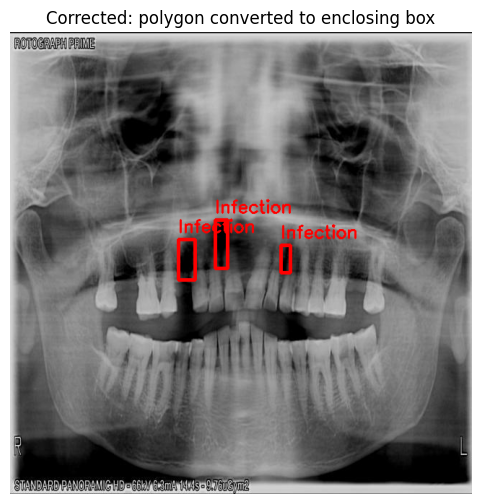

In [18]:
def draw_boxes_fixed(image_id, split):
    img_path = Path(DETECTION_ROOT) / split / 'images' / f'{image_id}.jpg'
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    rows = boxes_df_fixed[(boxes_df_fixed['image_id'] == image_id) & (boxes_df_fixed['split'] == split)]
    for _, row in rows.iterrows():
        x_c, y_c, bw, bh = row['x_center_norm'], row['y_center_norm'], row['width_norm'], row['height_norm']
        x1, y1 = int((x_c - bw/2) * w), int((y_c - bh/2) * h)
        x2, y2 = int((x_c + bw/2) * w), int((y_c + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.putText(img, row['class_name'], (x1, max(y1 - 10, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return img

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(draw_boxes_fixed('Infection_2684_jpg.rf.c3b91214ede40cc3513ab271be573c90', 'train'))
ax.set_title('Corrected: polygon converted to enclosing box')
ax.axis('off')
plt.show()

merge exact-duplicate images (union-find), so they're forced into one split:

In [19]:
parent = {img_id: img_id for img_id in images_df['image_id']}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for h, members in dup_hashes.items():
    ids = [stem for split, stem in members]
    for other in ids[1:]:
        union(ids[0], other)

images_df['final_group_id'] = images_df['image_id'].apply(find)
print("Final groups after merging exact duplicates:", images_df['final_group_id'].nunique(), "(was 10000)")

Final groups after merging exact duplicates: 9988 (was 10000)


multi-label stratified split, this time using the corrected labels

In [20]:
!pip install iterative-stratification -q

import numpy as np
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [21]:

id_to_group = images_df.set_index('image_id')['final_group_id'].to_dict()
boxes_df_fixed['final_group_id'] = boxes_df_fixed['image_id'].map(id_to_group)

group_classes = boxes_df_fixed.groupby('final_group_id')['class_id'].apply(set)
all_group_ids = sorted(images_df['final_group_id'].unique())
gid_to_idx = {g: i for i, g in enumerate(all_group_ids)}

Y = np.zeros((len(all_group_ids), NUM_CLASSES), dtype=int)
for gid, classes in group_classes.items():
    for c in classes:
        Y[gid_to_idx[gid], c] = 1

has_any = Y.sum(axis=1)
Y_ext = np.hstack([Y, (has_any == 0).astype(int).reshape(-1, 1)])
X_dummy = np.zeros((len(all_group_ids), 1))

msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
trainval_idx, test_idx = next(msss1.split(X_dummy, Y_ext))

msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=1/9, random_state=42)
train_idx_rel, val_idx_rel = next(msss2.split(X_dummy[trainval_idx], Y_ext[trainval_idx]))

all_group_arr = np.array(all_group_ids)
train_groups = set(all_group_arr[trainval_idx][train_idx_rel])
val_groups   = set(all_group_arr[trainval_idx][val_idx_rel])
test_groups  = set(all_group_arr[test_idx])

print(f"Groups -> train: {len(train_groups)}, val: {len(val_groups)}, test: {len(test_groups)}")

Groups -> train: 7991, val: 989, test: 1008


assign the split, verify stratification AND zero leakage together:

In [22]:
def assign_split(gid):
    if gid in train_groups: return 'train'
    if gid in val_groups: return 'val'
    return 'test'

images_df['final_split'] = images_df['final_group_id'].apply(assign_split)
print(images_df['final_split'].value_counts())

id_to_final_split = images_df.set_index('image_id')['final_split'].to_dict()
boxes_df_fixed['final_split'] = boxes_df_fixed['image_id'].map(id_to_final_split)

new_counts = boxes_df_fixed.groupby(['final_split', 'class_name']).size().unstack(fill_value=0)
new_counts['total'] = new_counts.sum(axis=1)
print("\nInstance counts:\n", new_counts)

pct = new_counts.drop(columns='total').div(new_counts['total'], axis=0).mul(100).round(1)
print("\nPercentages (check Wisdom/Infection are now consistent across rows):\n", pct)

leak_check = images_df.groupby('final_group_id')['final_split'].nunique()
print("\nGroups spanning more than one split (must be 0):", (leak_check > 1).sum())

final_split
train    7998
test     1009
val       993
Name: count, dtype: int64

Instance counts:
 class_name   Cavities  Damage  Infection  Wisdom  total
final_split                                            
test              680    1119        379     342   2520
train            5413    8525       2957    2877  19772
val               696    1051        351     364   2462

Percentages (check Wisdom/Infection are now consistent across rows):
 class_name   Cavities  Damage  Infection  Wisdom
final_split                                     
test             27.0    44.4       15.0    13.6
train            27.4    43.1       15.0    14.6
val              28.3    42.7       14.3    14.8

Groups spanning more than one split (must be 0): 0


 materialize the final dataset: symlink images (fast, no wasted disk space) into the new split folders, and write the corrected labels for real:

In [23]:
FINAL_DIR = Path('/kaggle/working/dental_final')
for s in ['train', 'val', 'test']:
    (FINAL_DIR / s / 'images').mkdir(parents=True, exist_ok=True)
    (FINAL_DIR / s / 'labels').mkdir(parents=True, exist_ok=True)

for _, row in images_df.iterrows():
    img_id, orig_split, final_split = row['image_id'], row['split'], row['final_split']

    src_img = Path(DETECTION_ROOT) / orig_split / 'images' / f'{img_id}.jpg'
    dst_img = FINAL_DIR / final_split / 'images' / f'{img_id}.jpg'
    if not dst_img.exists():
        os.symlink(src_img, dst_img)

    lines = corrected_labels.get(img_id, [])
    (FINAL_DIR / final_split / 'labels' / f'{img_id}.txt').write_text('\n'.join(lines))

for s in ['train', 'val', 'test']:
    n_img = len(list((FINAL_DIR / s / 'images').glob('*.jpg')))
    n_lbl = len(list((FINAL_DIR / s / 'labels').glob('*.txt')))
    print(f"{s}: {n_img} images, {n_lbl} labels")

final_yaml = {
    'train': str(FINAL_DIR / 'train' / 'images'),
    'val': str(FINAL_DIR / 'val' / 'images'),
    'test': str(FINAL_DIR / 'test' / 'images'),
    'nc': NUM_CLASSES,
    'names': CLASS_NAMES,
}
with open(FINAL_DIR / 'data.yaml', 'w') as f:
    yaml.dump(final_yaml, f)
print("\nFinal data.yaml ready at:", FINAL_DIR / 'data.yaml')

train: 7998 images, 7998 labels
val: 993 images, 993 labels
test: 1009 images, 1009 labels

Final data.yaml ready at: /kaggle/working/dental_final/data.yaml


measure actual brightness/contrast variation across the dataset:

       mean_brightness  std_contrast
count       800.000000    800.000000
mean        100.976625     51.058478
std          18.615698      8.784775
min          27.993853     22.400077
25%          88.157045     45.268515
50%         100.538771     51.973730
75%         113.999274     57.220084
max         169.583574     76.247174


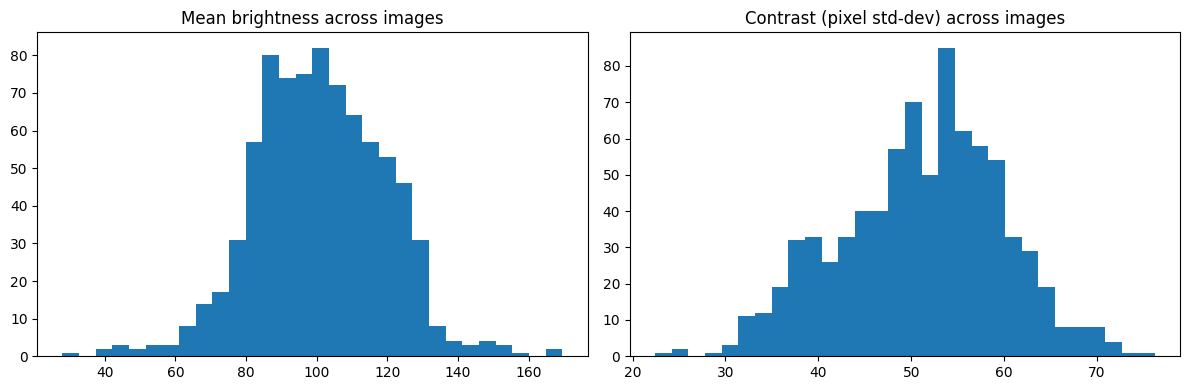


Brightness range: 28.0 to 169.6
Coefficient of variation (brightness): 18.4%


In [24]:
import random

sample_ids = images_df.sample(min(800, len(images_df)), random_state=42)

brightness_records = []
for _, row in sample_ids.iterrows():
    img_path = Path(DETECTION_ROOT) / row['split'] / 'images' / f"{row['image_id']}.jpg"
    with Image.open(img_path) as im:
        arr = np.array(im.convert('L'))  # grayscale intensity
    brightness_records.append({
        'image_id': row['image_id'],
        'mean_brightness': arr.mean(),
        'std_contrast': arr.std(),
    })

bright_df = pd.DataFrame(brightness_records)
print(bright_df[['mean_brightness', 'std_contrast']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(bright_df['mean_brightness'], bins=30)
axes[0].set_title('Mean brightness across images')
axes[1].hist(bright_df['std_contrast'], bins=30)
axes[1].set_title('Contrast (pixel std-dev) across images')
plt.tight_layout()
plt.show()

print(f"\nBrightness range: {bright_df['mean_brightness'].min():.1f} to {bright_df['mean_brightness'].max():.1f}")
print(f"Coefficient of variation (brightness): {(bright_df['mean_brightness'].std() / bright_df['mean_brightness'].mean() * 100):.1f}%")

In [25]:
import shutil

for _, row in images_df.iterrows():
    img_id, orig_split, final_split = row['image_id'], row['split'], row['final_split']
    src_img = Path(DETECTION_ROOT) / orig_split / 'images' / f'{img_id}.jpg'
    dst_img = FINAL_DIR / final_split / 'images' / f'{img_id}.jpg'
    if not dst_img.exists():
        if dst_img.is_symlink():
            dst_img.unlink()
        shutil.copy2(src_img, dst_img)

print("Symlinks replaced with real file copies — safe to package as a standalone Dataset now.")

Symlinks replaced with real file copies — safe to package as a standalone Dataset now.


In [26]:
p = FINAL_DIR / 'train' / 'images'
files = list(p.glob('*.jpg'))
print("Files found in current live session:", len(files))
if files:
    print("Is symlink:", files[0].is_symlink())

Files found in current live session: 7998
Is symlink: True


In [27]:
import zipfile

for s in ['train', 'val', 'test']:
    img_dir = FINAL_DIR / s / 'images'
    zip_path = FINAL_DIR / f'{s}_images.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_STORED) as zf:
        for img_id, row in images_df[images_df['final_split'] == s].iterrows():
            stem = images_df.loc[img_id, 'image_id']
            orig_split = images_df.loc[img_id, 'split']
            src_img = Path(DETECTION_ROOT) / orig_split / 'images' / f'{stem}.jpg'
            zf.write(src_img, arcname=f'{stem}.jpg')
    print(f"{s}: zipped {zip_path.stat().st_size / 1e6:.1f} MB -> {zip_path}")

train: zipped 305.4 MB -> /kaggle/working/dental_final/train_images.zip
val: zipped 38.6 MB -> /kaggle/working/dental_final/val_images.zip
test: zipped 38.7 MB -> /kaggle/working/dental_final/test_images.zip


In [28]:
try:
    print("FINAL_DIR:", FINAL_DIR)
    print("boxes_df_fixed rows:", len(boxes_df_fixed))
    print("CLASS_NAMES:", CLASS_NAMES)
    print("Session intact — good to continue.")
except NameError as e:
    print("Session was reset, variable missing:", e)
    print("We'll need to re-run the earlier cells before continuing.")

FINAL_DIR: /kaggle/working/dental_final
boxes_df_fixed rows: 24754
CLASS_NAMES: ['Cavities', 'Damage', 'Infection', 'Wisdom']
Session intact — good to continue.


In [29]:
import numpy as np
from PIL import Image

sample = images_df.sample(20, random_state=1)
max_diffs = []
for _, row in sample.iterrows():
    img_path = Path(DETECTION_ROOT) / row['split'] / 'images' / f"{row['image_id']}.jpg"
    arr = np.array(Image.open(img_path).convert('RGB')).astype(int)
    r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]
    max_diffs.append(max(np.abs(r - g).max(), np.abs(g - b).max(), np.abs(r - b).max()))

print("Max R/G/B channel difference across 20 sampled images:", max(max_diffs))
print("Near 0 => effectively grayscale => hue/saturation jitter has no real effect.")

Max R/G/B channel difference across 20 sampled images: 0
Near 0 => effectively grayscale => hue/saturation jitter has no real effect.


In [30]:
AUGMENTATION_CONFIG = {
    # Photometric
    'hsv_h': 0.0,     # DISABLED — verified images are effectively grayscale
                      # (max R/G/B channel difference = 0 across sampled images),
                      # so hue jitter has no meaningful effect on this data
    'hsv_s': 0.0,     # DISABLED — same reason; no real saturation to jitter
    'hsv_v': 0.4,     # KEPT, and the one photometric param with real backing —
                      # measured brightness range 28-170 (CV 18.4%) and contrast
                      # std range 22-76 across the dataset (Cell 19)

    # Geometric
    'fliplr': 0.5,    # dental findings are plausibly mirrored; not like text/signage
                      # where flip changes meaning. Note: sample images carry burned-in
                      # L/R laterality markers, which also get mirrored — worth checking
                      # for in error analysis, not a reason to disable flip
    'flipud': 0.0,    # patients are always upright during capture; an upside-down
                      # OPG never occurs in practice — geometric/capture argument,
                      # not something that needed measuring
    'degrees': 10,    # conservative standard default, not derived from a specific
                      # measurement — stated plainly as such
    'translate': 0.1, # same — conservative default
    'scale': 0.3,     # backed by measured bbox area spread post-polygon-fix
                      # (small 15.1%, medium 82.6%, large 2.4%)

    # Mosaic
    'mosaic': 1.0,    # justified by measured small-object proportion (15.1%) —
                      # mosaic increases scale/context diversity per training image.
                      # NOT a fix for class imbalance (that's handled via class-weighted
                      # loss/oversampling in Notebooks 2-5, not augmentation)
    'close_mosaic': 10,  # disabled for final 10 epochs so the model fine-tunes on
                          # realistic, non-stitched images before training ends —
                          # extra important here since mosaic stitching combined with
                          # this dataset's naturally dense/overlapping findings
                          # (up to 15 per image) risks excessive crowding

    'overlap_mask': True,  # justified by the dense, overlapping findings observed
                           # in sample images
    'copy_paste': 0.0,     # measured imbalance ratio is 2.98x across 4 classes —
                           # doesn't clear this project's own guidance-table threshold
                           # (">5 classes or severe imbalance") for enabling this
}
print("Corrected augmentation config set.")

Corrected augmentation config set.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ Slow image access detected (ping: 0.0±0.0 ms, read: 47.5±7.9 MB/s, size: 33.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
Scanning /kaggle/working/dental_final/train/labels... 7998 images, 141 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7998/7998 1.5Kit/s 5.3s
New cache created: /kaggle/working/dental_final/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


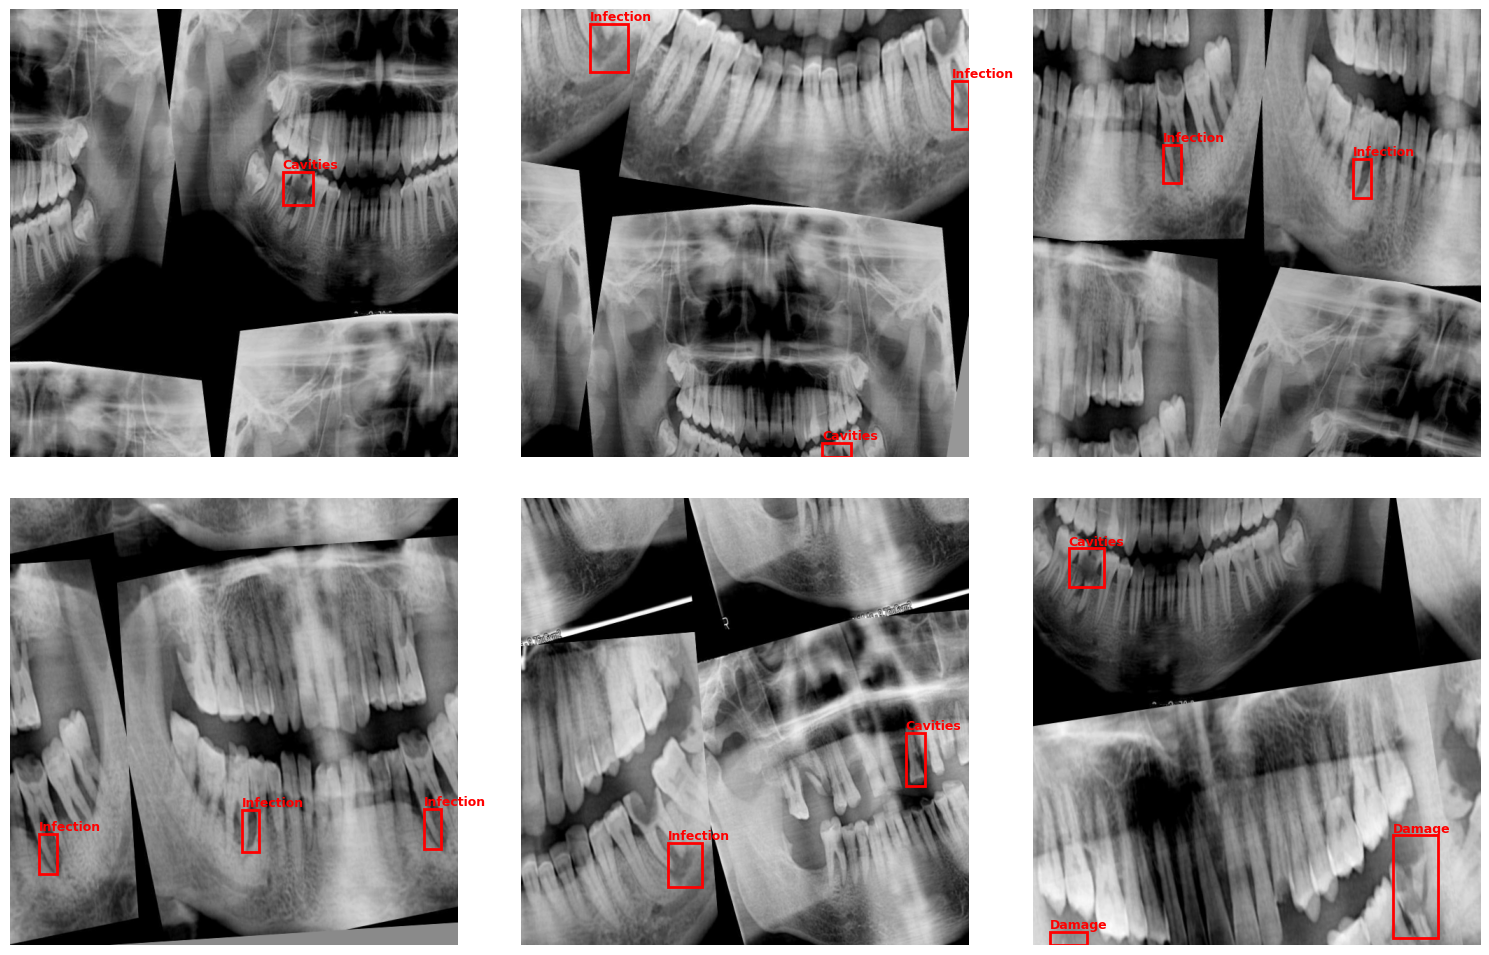

In [31]:
from ultralytics.data.dataset import YOLODataset
from ultralytics.utils import DEFAULT_CFG
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

cfg = deepcopy(DEFAULT_CFG)
for k, v in AUGMENTATION_CONFIG.items():
    setattr(cfg, k, v)
cfg.imgsz = IMG_SIZE

dataset = YOLODataset(
    img_path=str(FINAL_DIR / 'train' / 'images'),
    data={'names': {i: n for i, n in enumerate(CLASS_NAMES)}, 'nc': NUM_CLASSES, 'channels': 3},
    augment=True,
    hyp=cfg,
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax in axes.flat:
    sample = dataset[np.random.randint(len(dataset))]
    img = sample['img'].permute(1, 2, 0).numpy()
    boxes = sample['bboxes'].numpy()
    classes = sample['cls'].numpy().flatten()

    h, w = img.shape[:2]
    ax.imshow(img)
    for box, cls in zip(boxes, classes):
        x_c, y_c, bw, bh = box
        x1, y1 = (x_c - bw / 2) * w, (y_c - bh / 2) * h
        rect = plt.Rectangle((x1, y1), bw * w, bh * h, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), CLASS_NAMES[int(cls)], color='red', fontsize=9, weight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

Damage: center=(0.959,0.693) size=(0.072,0.120)
Damage: center=(0.938,0.514) size=(0.072,0.118)
---
Infection: center=(0.305,0.008) size=(0.043,0.017)
Damage: center=(0.017,0.774) size=(0.034,0.165)
Damage: center=(0.088,0.676) size=(0.064,0.145)
Infection: center=(0.966,0.668) size=(0.067,0.108)
---
Damage: center=(0.202,0.060) size=(0.084,0.119)
Damage: center=(0.089,0.043) size=(0.055,0.085)
Infection: center=(0.740,0.182) size=(0.158,0.082)
Damage: center=(0.199,0.200) size=(0.087,0.168)
---
Infection: center=(0.759,0.184) size=(0.119,0.098)
---


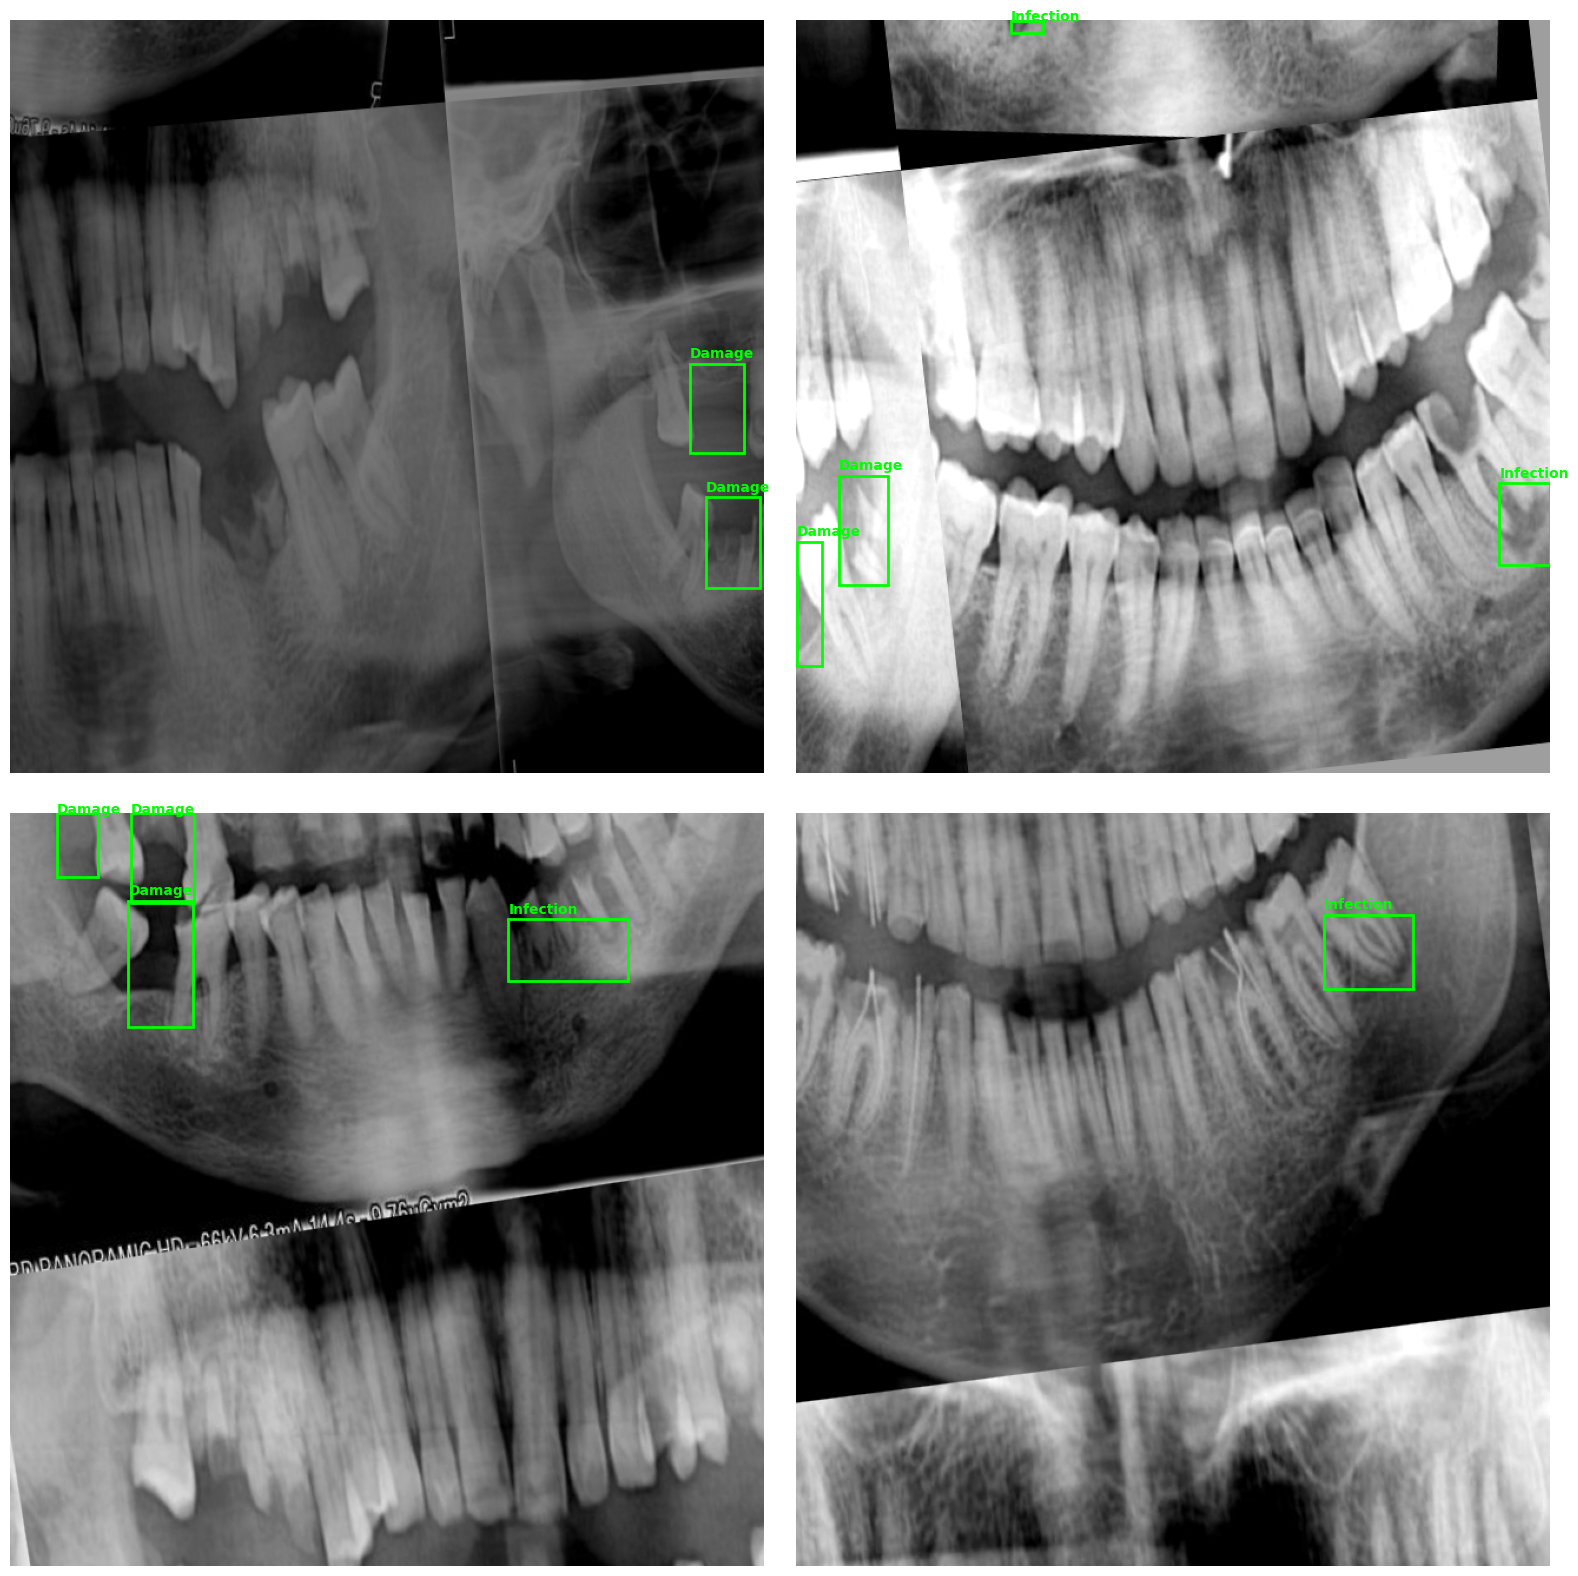

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
for ax in axes.flat:
    sample = dataset[np.random.randint(len(dataset))]
    img = sample['img'].permute(1, 2, 0).numpy()
    boxes = sample['bboxes'].numpy()
    classes = sample['cls'].numpy().flatten()
    h, w = img.shape[:2]

    ax.imshow(img)
    for box, cls in zip(boxes, classes):
        x_c, y_c, bw, bh = box
        x1, y1 = (x_c - bw / 2) * w, (y_c - bh / 2) * h
        rect = plt.Rectangle((x1, y1), bw * w, bh * h, fill=False, color='lime', linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), CLASS_NAMES[int(cls)], color='lime', fontsize=10, weight='bold')
        print(f"{CLASS_NAMES[int(cls)]}: center=({x_c:.3f},{y_c:.3f}) size=({bw:.3f},{bh:.3f})")
    ax.axis('off')
    print('---')
plt.tight_layout()
plt.show()

Fast image access ✅ (ping: 0.0±0.0 ms, read: 51.2±10.5 MB/s, size: 36.1 KB)
Scanning /kaggle/working/dental_final/train/labels.cache... 7998 images, 141 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7998/7998 1.5Git/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


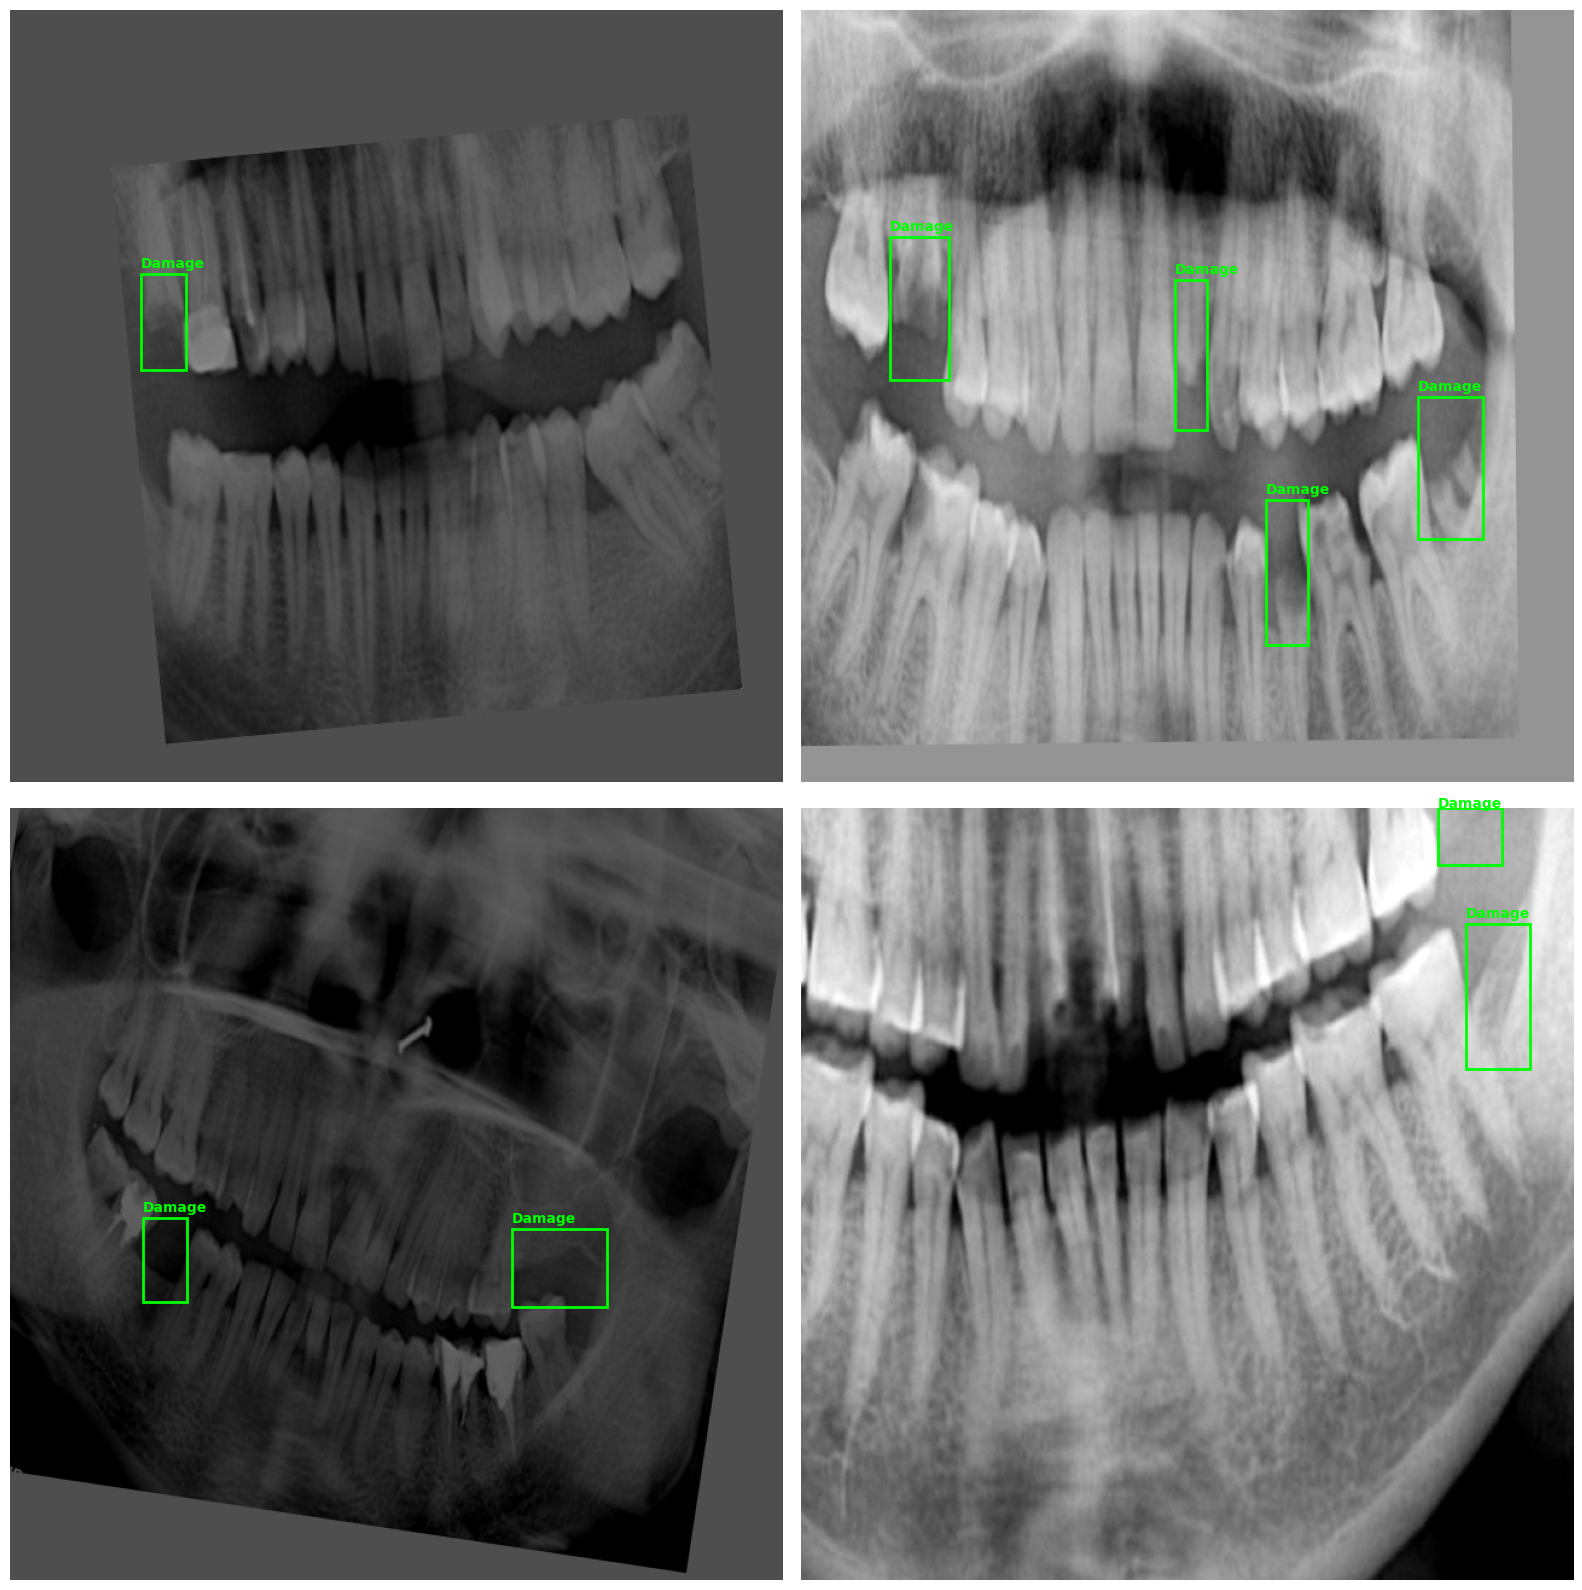

In [33]:
cfg_no_mosaic = deepcopy(DEFAULT_CFG)
for k, v in AUGMENTATION_CONFIG.items():
    setattr(cfg_no_mosaic, k, v)
cfg_no_mosaic.mosaic = 0.0
cfg_no_mosaic.imgsz = IMG_SIZE

dataset_no_mosaic = YOLODataset(
    img_path=str(FINAL_DIR / 'train' / 'images'),
    data={'names': {i: n for i, n in enumerate(CLASS_NAMES)}, 'nc': NUM_CLASSES, 'channels': 3},
    augment=True,
    hyp=cfg_no_mosaic,
)

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
for ax in axes.flat:
    sample = dataset_no_mosaic[np.random.randint(len(dataset_no_mosaic))]
    img = sample['img'].permute(1, 2, 0).numpy()
    boxes = sample['bboxes'].numpy()
    classes = sample['cls'].numpy().flatten()
    h, w = img.shape[:2]
    ax.imshow(img)
    for box, cls in zip(boxes, classes):
        x_c, y_c, bw, bh = box
        x1, y1 = (x_c - bw / 2) * w, (y_c - bh / 2) * h
        rect = plt.Rectangle((x1, y1), bw * w, bh * h, fill=False, color='lime', linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 5, 0), CLASS_NAMES[int(cls)], color='lime', fontsize=10, weight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [34]:
import numpy as np

def check_boxes(ds, n=500, label=""):
    total_boxes, out_of_bounds, zero_size = 0, 0, 0
    for _ in range(n):
        sample = ds[np.random.randint(len(ds))]
        boxes = sample['bboxes'].numpy()
        for box in boxes:
            x_c, y_c, bw, bh = box
            total_boxes += 1
            x1, y1, x2, y2 = x_c - bw/2, y_c - bh/2, x_c + bw/2, y_c + bh/2
            if x1 < -1e-4 or y1 < -1e-4 or x2 > 1 + 1e-4 or y2 > 1 + 1e-4:
                out_of_bounds += 1
            if bw <= 0 or bh <= 0:
                zero_size += 1
    print(f"--- {label} ---")
    print(f"Checked {n} samples, {total_boxes} total boxes")
    print(f"Out-of-bounds boxes: {out_of_bounds} ({out_of_bounds/total_boxes*100:.2f}%)")
    print(f"Zero/negative-size boxes: {zero_size}\n")

check_boxes(dataset, n=500, label="WITH mosaic (mosaic=1.0)")
check_boxes(dataset_no_mosaic, n=500, label="WITHOUT mosaic (mosaic=0.0)")

--- WITH mosaic (mosaic=1.0) ---
Checked 500 samples, 1674 total boxes
Out-of-bounds boxes: 0 (0.00%)
Zero/negative-size boxes: 0

--- WITHOUT mosaic (mosaic=0.0) ---
Checked 500 samples, 1207 total boxes
Out-of-bounds boxes: 0 (0.00%)
Zero/negative-size boxes: 0



In [35]:
print(dataset_no_mosaic.labels[0].keys())
print(dataset_no_mosaic.labels[0]['im_file'])
print(dataset_no_mosaic.labels[0]['bboxes'][:3])
print(dataset_no_mosaic.labels[0]['cls'][:3])

dict_keys(['im_file', 'shape', 'cls', 'bboxes', 'segments', 'keypoints', 'normalized', 'bbox_format'])
/kaggle/working/dental_final/train/images/Cavities_1000_jpg.rf.c46dfdec3e110481fc2a0cbfdf31130d.jpg
[[    0.66406     0.63359    0.060937    0.060156]
 [    0.65547     0.74063    0.041406    0.051562]
 [    0.76484     0.48906    0.034375    0.074219]]
[[          0]
 [          2]
 [          0]]


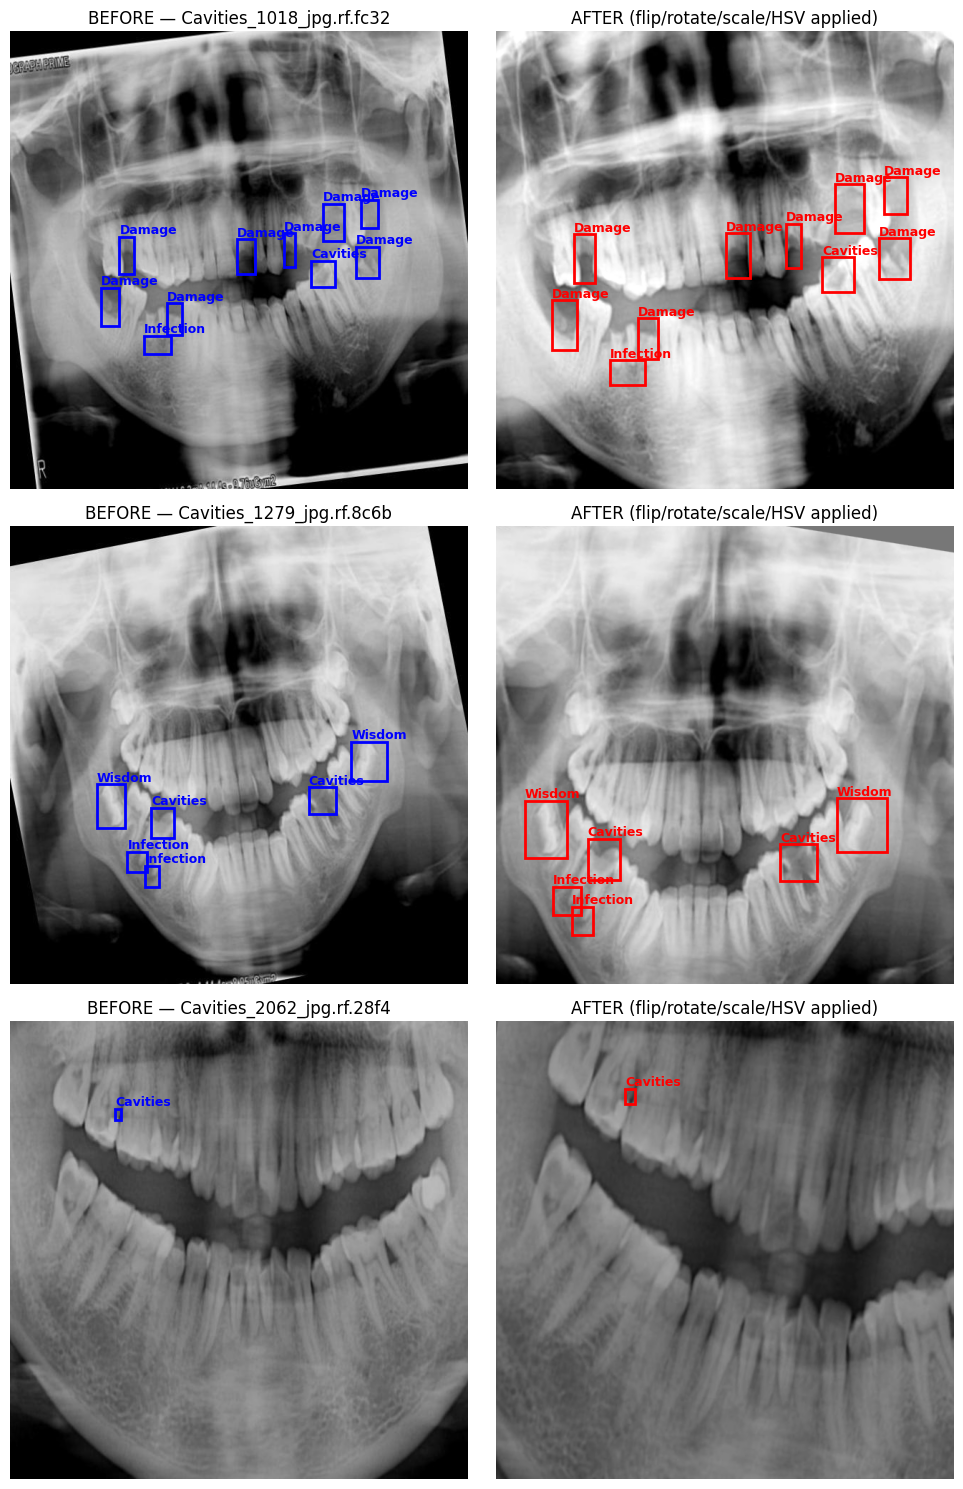

In [36]:
import cv2
from pathlib import Path

sample_indices = [10, 200, 800]  # a few fixed, reproducible examples

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(10, 5 * len(sample_indices)))

for row_idx, idx in enumerate(sample_indices):
    label_info = dataset_no_mosaic.labels[idx]
    img_path = label_info['im_file']
    orig_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    orig_boxes = label_info['bboxes']
    orig_classes = label_info['cls'].flatten()
    h, w = orig_img.shape[:2]

    ax_before = axes[row_idx, 0]
    ax_before.imshow(orig_img)
    for box, cls in zip(orig_boxes, orig_classes):
        x_c, y_c, bw, bh = box
        x1, y1 = (x_c - bw / 2) * w, (y_c - bh / 2) * h
        rect = plt.Rectangle((x1, y1), bw * w, bh * h, fill=False, color='blue', linewidth=2)
        ax_before.add_patch(rect)
        ax_before.text(x1, max(y1 - 5, 0), CLASS_NAMES[int(cls)], color='blue', fontsize=9, weight='bold')
    ax_before.set_title(f'BEFORE — {Path(img_path).stem[:25]}')
    ax_before.axis('off')

    sample = dataset_no_mosaic[idx]
    aug_img = sample['img'].permute(1, 2, 0).numpy()
    aug_boxes = sample['bboxes'].numpy()
    aug_classes = sample['cls'].numpy().flatten()
    ah, aw = aug_img.shape[:2]

    ax_after = axes[row_idx, 1]
    ax_after.imshow(aug_img)
    for box, cls in zip(aug_boxes, aug_classes):
        x_c, y_c, bw, bh = box
        x1, y1 = (x_c - bw / 2) * aw, (y_c - bh / 2) * ah
        rect = plt.Rectangle((x1, y1), bw * aw, bh * ah, fill=False, color='red', linewidth=2)
        ax_after.add_patch(rect)
        ax_after.text(x1, max(y1 - 5, 0), CLASS_NAMES[int(cls)], color='red', fontsize=9, weight='bold')
    ax_after.set_title('AFTER (flip/rotate/scale/HSV applied)')
    ax_after.axis('off')

plt.tight_layout()
plt.show()

This dataset contains 10,000 dental panoramic X-rays (640×640, single resolution) across four classes, with a genuine class imbalance (Damage ~43% of instances, Cavities ~27%, Infection and Wisdom ~14–15% each — a 2.98× ratio). During EDA we discovered roughly 17.6% of instances (concentrated in Infection at 51% and Cavities at 27%) were labeled as segmentation polygons rather than bounding boxes, which we converted to minimal enclosing rectangles; this corrected an earlier miscalculation of object size distribution (post-fix: 82.6% medium, 15.1% small, 2.4% large, by COCO area convention). The original Roboflow-provided split showed severe stratification failure for Wisdom and Infection (18.5% of train vs. ~1% of validation/test), so we rebuilt an 80/10/10 group-aware, multi-label stratified split, additionally merging 12 exact-duplicate images to guarantee zero cross-split leakage. We verified images are effectively grayscale (0 channel difference across samples), so hue/saturation augmentation was disabled as ineffective; measured brightness (range 28–170, CV 18.4%) justified real brightness/contrast augmentation instead. Paired before/after visualization and a quantitative check across 500 augmented batches (1,456+ boxes) confirmed zero out-of-bounds or malformed boxes, validating that our augmentation pipeline preserves label alignment. These characteristics — persistent class imbalance, moderate small-object presence, and confirmed grayscale/brightness properties — directly motivate class-weighted loss consideration in Notebooks 2–5 and support keeping imgsz=640 given the dataset's native resolution and the project's time constraints.